In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from utils.constants import *

# Load English datasets
en_data = {}
en_data['2020'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_EN_2020))
en_data['2025'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_EN_2025))

# Load German datasets
de_data = {}
de_data['2020'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_DE_2020))
de_data['2025'] = pd.read_csv(os.path.join(ASSET_DIR, CSV_DE_2025))

print(f"English data loaded:")
for year, df in en_data.items():
    print(f"  {year}: shape {df.shape}")

print(f"German data loaded:")
for year, df in de_data.items():
    print(f"  {year}: shape {df.shape}")


English data loaded:
  2020: shape (103192, 11)
  2025: shape (72726, 11)
German data loaded:
  2020: shape (4654, 11)
  2025: shape (22669, 11)


In [3]:
# Dataset overview for EDA
overview_rows = []
for lang_name, data_dict in [('English', en_data), ('German', de_data)]:
    for year, df in data_dict.items():
        text_col = 'full_text' if 'full_text' in df.columns else df.columns[0]
        text_lengths = df[text_col].fillna('').astype(str).str.len()
        overview_rows.append({
            'language': lang_name,
            'year': year,
            'rows': len(df),
            'columns': df.shape[1],
            'missing_full_text': int(df[text_col].isna().sum()),
            'avg_text_length': float(text_lengths.mean()),
            'median_text_length': float(text_lengths.median()),
            'unique_subreddits': int(df['subreddit'].nunique()) if 'subreddit' in df.columns else np.nan,
        })

overview_df = pd.DataFrame(overview_rows)
print('Dataset overview:')
display(overview_df.sort_values(['language', 'year']).reset_index(drop=True))

# Quick sanity checks for EDA coverage
for lang_name, data_dict in [('English', en_data), ('German', de_data)]:
    all_texts = pd.concat([df['full_text'] for df in data_dict.values()], ignore_index=True).fillna('')
    all_texts = all_texts[all_texts.str.strip() != '']
    print(f'{lang_name}: total non-empty texts = {len(all_texts)}')
    print(f'{lang_name}: sample longest text length = {all_texts.str.len().max() if len(all_texts) else 0}')


Dataset overview:


,language,year,rows,columns,missing_full_text,avg_text_length,median_text_length,unique_subreddits
0,English,2020,103192,11,0,914.147492,722.0,NaN
1,English,2025,72726,11,0,920.181654,733.0,NaN
2,German,2020,4654,11,0,989.830468,752.5,NaN
3,German,2025,22669,11,0,875.140809,648.0,NaN


English: total non-empty texts = 175918
English: sample longest text length = 26724
German: total non-empty texts = 27323
German: sample longest text length = 24032


post_count vs fdi

In [4]:
from utils.post_count import create_post_counts_csv

post_count_csv = os.path.join(ASSET_DIR, CSV_POST_COUNT)
if not os.path.exists(post_count_csv):
	create_post_counts_csv()
	print(f"Generated: {post_count_csv}")
else:
	print(f"Already exists: {post_count_csv}")

Already exists: ./asset/post_counts.csv


English (personalfinance) Pearson Correlation: r=-0.7999, p-value=0.0560
German (finanzen) Pearson Correlation: r=0.6645, p-value=0.1500


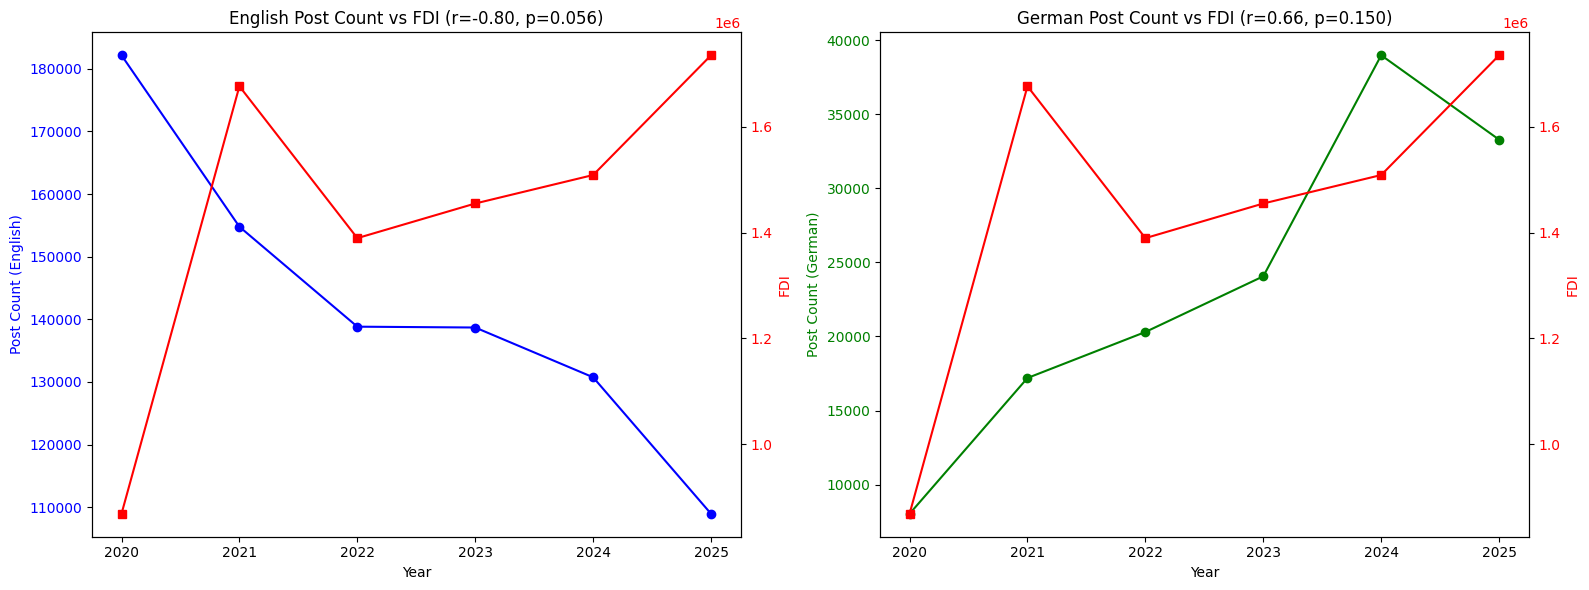

In [6]:
from scipy import stats

# Load post count and FDI data
# fdi data source https://unctadstat.unctad.org/datacentre/dataviewer/US.FdiFlowsStock
post_count_df = pd.read_csv(post_count_csv)
fdi_df = pd.read_csv(os.path.join(ASSET_DIR, CSV_FDI))

# Pivot post counts so each subreddit becomes its own column
# personalfinance -> English, finanzen -> German
pivot = post_count_df.pivot(index='year', columns='subreddit', values='count').reset_index()
pivot = pivot.rename(columns={'personalfinance': 'post_count_en', 'finanzen': 'post_count_de'})
# Ensure both columns exist
if 'post_count_en' not in pivot.columns:
    pivot['post_count_en'] = 0
if 'post_count_de' not in pivot.columns:
    pivot['post_count_de'] = 0

# Merge by year (now contains post_count_en and post_count_de)
merged_df = pd.merge(pivot, fdi_df, on='year', how='inner')
merged_df = merged_df.sort_values('year')

# Statistical Analysis: compute correlations separately for English and German
def compute_and_print_corr(x, y, label):
    if x.isna().all():
        print(f"No data for {label}")
        return np.nan, np.nan
    corr, p_value = stats.pearsonr(x, y)
    print(f"{'='*60}")
    print(f"{label} Pearson Correlation: r={corr:.4f}, p-value={p_value:.4f}")
    return corr, p_value

en_corr, en_p = compute_and_print_corr(merged_df['post_count_en'], merged_df['fdi'], 'English (personalfinance)')
de_corr, de_p = compute_and_print_corr(merged_df['post_count_de'], merged_df['fdi'], 'German (finanzen)')

def fmt_p(p_value):
    if pd.isna(p_value):
        return 'p=NA'
    if p_value < 0.001:
        return 'p<0.001'
    return f'p={p_value:.3f}'

# Plots for English and German post counts vs FDI over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# English
ax1 = axes[0]
ax1.plot(merged_df['year'], merged_df['post_count_en'], marker='o', color='blue', label='Post Count EN')
ax1.set_xlabel('Year')
ax1.set_ylabel('Post Count (English)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(merged_df['year'])
ax1.set_title(f'English Post Count vs FDI (r={en_corr:.2f}, {fmt_p(en_p)})')

ax1_fdi = ax1.twinx()
ax1_fdi.plot(merged_df['year'], merged_df['fdi'], marker='s', color='red', label='FDI')
ax1_fdi.set_ylabel('FDI', color='red')
ax1_fdi.tick_params(axis='y', labelcolor='red')

# German
ax2 = axes[1]
ax2.plot(merged_df['year'], merged_df['post_count_de'], marker='o', color='green', label='Post Count DE')
ax2.set_xlabel('Year')
ax2.set_ylabel('Post Count (German)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.set_xticks(merged_df['year'])
ax2.set_title(f'German Post Count vs FDI (r={de_corr:.2f}, {fmt_p(de_p)})')

ax2_fdi = ax2.twinx()
ax2_fdi.plot(merged_df['year'], merged_df['fdi'], marker='s', color='red', label='FDI')
ax2_fdi.set_ylabel('FDI', color='red')
ax2_fdi.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
corr_fig = os.path.join(ASSET_DIR, f'correlation_plot.png')
plt.savefig(corr_fig, dpi=300, bbox_inches='tight')
plt.show()


NER via Spacy

In [5]:
# Load spaCy models (via utils to optionally attach spacy-duckling)
from utils.ner import build_nlp_models

en_nlp, de_nlp = build_nlp_models(EN_MODEL, DE_MODEL)

# Function to extract entities
def extract_entities(text, nlp_model):
    if pd.isna(text):
        return []
    doc = nlp_model(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

Duckling HTTP attached to German model at http://localhost:8000/parse


In [ ]:
# Analyze entity distribution (by year) using all available texts
def analyze_entities_by_year(data_dict, nlp_model, lang_name, batch_size=64):
    """Extract and map entities, returning dict with year-indexed entity distributions."""
    yearly_entities = {}
    for year, df in data_dict.items():
        all_entities = []
        # df = df.sample(n=10, random_state=42) if len(df) > 10 else df
        text_rows = df[['id', 'full_text', 'created_utc']].dropna(subset=['full_text']).copy()
        text_rows['full_text'] = text_rows['full_text'].astype(str)
        text_rows = text_rows[text_rows['full_text'].str.strip() != '']
        print(f"{lang_name} {year}: processing {len(text_rows)} texts in batches of {batch_size}")
        row_items = list(text_rows[['id', 'full_text', 'created_utc']].itertuples(index=True, name='RowItem'))
        row_entity_records = []
        for row_item, doc in zip(row_items, nlp_model.pipe(text_rows['full_text'].tolist(), batch_size=batch_size)):
            for ent in doc.ents:
                canonical = NER_DICT.get(ent.label_)
                if canonical:
                    all_entities.append((ent.text, canonical))
                    row_entity_records.append({
                        'id': row_item.id,
                        'created_utc': row_item.created_utc,
                        'language': lang_name,
                        'year': year,
                        'row_index': row_item.Index,
                        'entity_text': ent.text,
                        'entity_label': canonical,
                    })
        row_entity_df = pd.DataFrame(row_entity_records)
        row_entity_csv = os.path.join(ASSET_DIR, 'ner_entity_labels_by_row.csv')
        write_header = not os.path.exists(row_entity_csv)
        row_entity_df.to_csv(row_entity_csv, mode='a', index=False, header=write_header)
        print(f"✓ Saved row-level NER labels for {lang_name} {year} to: {row_entity_csv}")
        
        # Count entity types
        entity_types = {}
        for text, label in all_entities:
            entity_types[label] = entity_types.get(label, 0) + 1
        
        yearly_entities[year] = entity_types
        print(f"\n{lang_name} {year}: Total entities extracted: {sum(entity_types.values())}")
        for label, count in sorted(entity_types.items(), key=lambda x: x[1], reverse=True):
            print(f"  {label}: {count}")
    
    return yearly_entities

# Analyze English and German entities by year
english_entities_by_year = analyze_entities_by_year(en_data, en_nlp, "English", batch_size=64)
german_entities_by_year = analyze_entities_by_year(de_data, de_nlp, "German", batch_size=64)

# Build heatmap with 4 columns: English 2020, English 2025, German 2020, German 2025
heatmap_data = {}
heatmap_data['English 2020'] = english_entities_by_year.get('2020', {})
heatmap_data['English 2025'] = english_entities_by_year.get('2025', {})
heatmap_data['German 2020'] = german_entities_by_year.get('2020', {})
heatmap_data['German 2025'] = german_entities_by_year.get('2025', {})

# Create raw count dataframe
heatmap_df_raw = pd.DataFrame(heatmap_data).fillna(0).astype(int)

# Standardize to z-scores (column-wise: each dataset/language-year independently normalized)
from scipy.stats import zscore
heatmap_df_zscore = heatmap_df_raw.astype(float).apply(zscore, axis=0, nan_policy='propagate')
# Replace NaN (which occurs when std=0 for a column) with 0
heatmap_df_zscore = heatmap_df_zscore.fillna(0)

# Save raw counts to CSV
output_csv_raw = os.path.join(ASSET_DIR, 'ner_entity_counts_raw.csv')
heatmap_df_raw.to_csv(output_csv_raw)
print(f"\n✓ Saved raw entity counts to: {output_csv_raw}")

# Save z-scores to CSV
output_csv_zscore = os.path.join(ASSET_DIR, 'ner_entity_counts_zscore.csv')
heatmap_df_zscore.to_csv(output_csv_zscore)
print(f"✓ Saved z-score normalized counts to: {output_csv_zscore}")

# Statistical test: Compare distributions across language and year
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(heatmap_df_raw.values)
print(f"\n{'='*60}")
print(f"Chi-Square Test (Language × Year effect on entity distribution):")
print(f"  χ² = {chi2:.4f}, p-value = {p_value:.4f}, dof = {dof}")
if p_value < 0.05:
    print(f"  → Significant difference detected (p < 0.05)")
else:
    print(f"  → No significant difference detected (p ≥ 0.05)")
print(f"{'='*60}")

# Save chi-square results to a text file
output_stats = os.path.join(ASSET_DIR, 'ner_chi_square_results.txt')
with open(output_stats, 'w') as f:
    f.write("NER Entity Distribution - Chi-Square Test Results\n")
    f.write("="*60 + "\n")
    f.write(f"χ² = {chi2:.4f}\n")
    f.write(f"p-value = {p_value:.4f}\n")
    f.write(f"dof = {dof}\n")
    f.write(f"Significant (p < 0.05): {p_value < 0.05}\n")
    f.write("="*60 + "\n")
    f.write("\nEntity Distribution Summary:\n")
    f.write(heatmap_df_raw.to_string())
print(f"✓ Saved chi-square results to: {output_stats}")


English 2020: processing 103192 texts in batches of 64
✓ Saved row-level NER labels for English 2020 to: ./asset/ner_entity_labels_by_row.csv

English 2020: Total entities extracted: 870197
  TIME: 280533
  CARDINAL: 174475
  MONEY: 160185
  ORG: 148008
  GPE: 45814
  PERSON: 33463
  ORDINAL: 27719
English 2025: processing 72726 texts in batches of 64
✓ Saved row-level NER labels for English 2025 to: ./asset/ner_entity_labels_by_row.csv

English 2025: Total entities extracted: 647186
  TIME: 192658
  CARDINAL: 144727
  MONEY: 135614
  ORG: 102432
  PERSON: 27555
  GPE: 26951
  ORDINAL: 17249
German 2020: processing 4654 texts in batches of 64
✓ Saved row-level NER labels for German 2020 to: ./asset/ner_entity_labels_by_row.csv

German 2020: Total entities extracted: 54751
  CARDINAL: 25217
  ORG: 7718
  TIME: 7296
  MONEY: 5041
  GPE: 4394
  PERSON: 3212
  ORDINAL: 1873
German 2025: processing 22669 texts in batches of 64
✓ Saved row-level NER labels for German 2025 to: ./asset/ner_ent


NER Entity Distribution - Chi-Square Test Results
χ² = 108897.6706
p-value = 0.0000
dof = 18
Significant (p < 0.05): True

Entity Distribution Summary:
          English 2020  English 2025  German 2020  German 2025
TIME            280533        192658         7296        34477
MONEY           160185        135614         5041        22194
CARDINAL        174475        144727        25217       106876
ORDINAL          27719         17249         1873         7626
ORG             148008        102432         7718        32810
PERSON           33463         27555         3212        14501
GPE              45814         26951         4394        18834
Loaded heatmap data: ./asset/result_1205/eda/ner_entity_counts_raw.csv, ./asset/result_1205/eda/ner_entity_counts_zscore.csv
✓ Saved heatmap (z-score): ./asset/result_1205/eda/ner_entity_counts_heatmap_zscore.png


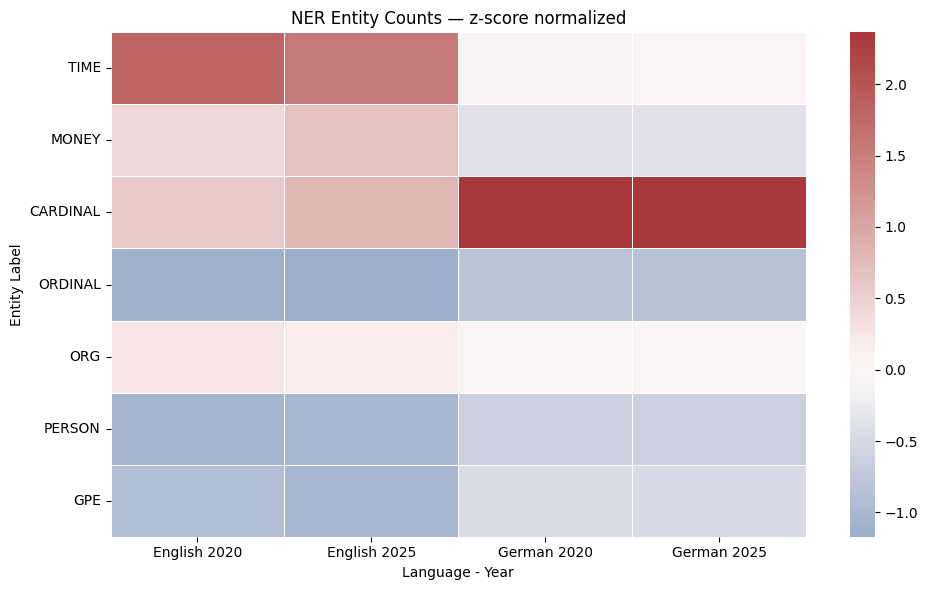

✓ Saved heatmap (raw, log scale): ./asset/result_1205/eda/ner_entity_counts_heatmap_raw.png


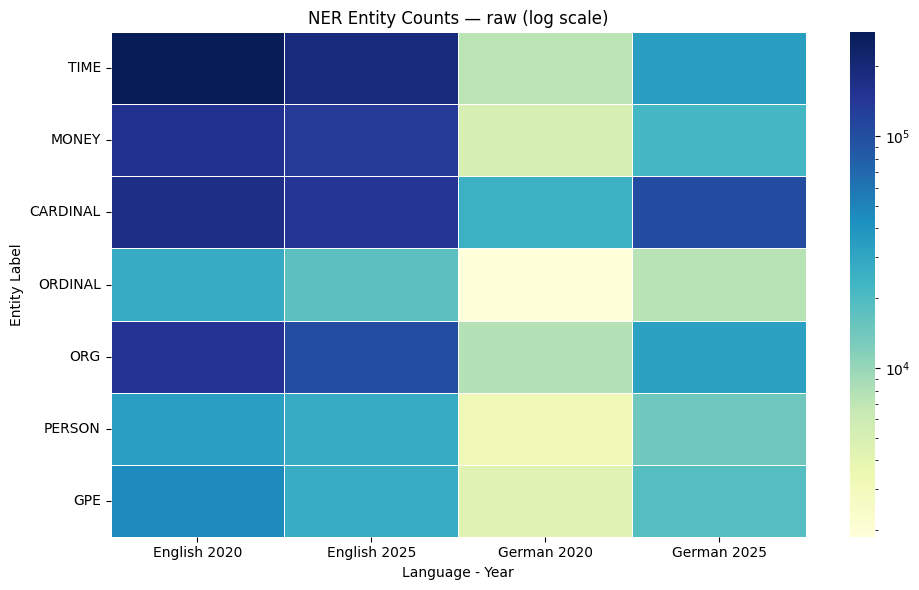

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from utils.constants import *
output_stats = os.path.join(ASSET_DIR, 'result_1205', 'eda', 'ner_chi_square_results.txt')
# Read chi-square results and plot saved heatmaps
try:
    with open(output_stats, 'r') as f:
        print('\n' + f.read())
except Exception as e:
    print(f'Could not read chi-square results: {e}')

# Load raw counts and z-score normalized counts
try:
    raw_counts_path = os.path.join(ASSET_DIR, 'result_1205', 'eda', 'ner_entity_counts_raw.csv')
    zscore_path = os.path.join(ASSET_DIR, 'result_1205', 'eda', 'ner_entity_counts_zscore.csv')
    heatmap_df_raw = pd.read_csv(raw_counts_path, index_col=0)
    heatmap_df_zscore = pd.read_csv(zscore_path, index_col=0)
    print(f'Loaded heatmap data: {raw_counts_path}, {zscore_path}')
except Exception as e:
    print(f'Error loading heatmap CSVs: {e}')
    heatmap_df_raw = None
    heatmap_df_zscore = None

# Plot z-score heatmap (centered)
import seaborn as sns
from matplotlib.colors import LogNorm

if heatmap_df_zscore is not None and not heatmap_df_zscore.empty:
    plt.figure(figsize=(10, max(6, heatmap_df_zscore.shape[0] * 0.3)))
    sns.heatmap(heatmap_df_zscore, cmap='vlag', center=0, linewidths=0.5)
    plt.title('NER Entity Counts — z-score normalized')
    plt.xlabel('Language - Year')
    plt.ylabel('Entity Label')
    plt.tight_layout()
    out_z = os.path.join(ASSET_DIR, 'result_1205', 'eda', 'ner_entity_counts_heatmap_zscore.png')
    plt.savefig(out_z, dpi=300, bbox_inches='tight')
    print(f'✓ Saved heatmap (z-score): {out_z}')
    plt.show()

# Plot raw counts heatmap (log scale to handle skew)
if heatmap_df_raw is not None and not heatmap_df_raw.empty:
    plt.figure(figsize=(10, max(6, heatmap_df_raw.shape[0] * 0.3)))
    # Determine vmin for LogNorm (smallest positive value)
    positive_vals = heatmap_df_raw[heatmap_df_raw > 0]
    if positive_vals.any().any():
        vmin = positive_vals.stack().min()
    else:
        vmin = 1
    norm = LogNorm(vmin=vmin, vmax=heatmap_df_raw.max().max())
    sns.heatmap(heatmap_df_raw, cmap='YlGnBu', norm=norm, linewidths=0.5)
    plt.title('NER Entity Counts — raw (log scale)')
    plt.xlabel('Language - Year')
    plt.ylabel('Entity Label')
    plt.tight_layout()
    out_raw = os.path.join(ASSET_DIR, 'result_1205', 'eda', 'ner_entity_counts_heatmap_raw.png')
    plt.savefig(out_raw, dpi=300, bbox_inches='tight')
    print(f'✓ Saved heatmap (raw, log scale): {out_raw}')
    plt.show()


In [20]:
# TF-IDF analysis (based on lecture: tokenization, TF, IDF, TF-IDF ranking, n-grams)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from spacy.lang.de.stop_words import STOP_WORDS as DE_STOP_WORDS

def prepare_texts(data_dict, text_col="full_text"):
    grouped = {}
    for year, df in data_dict.items():
        if text_col not in df.columns:
            print(f"{year}: column '{text_col}' not found, skipping")
            continue
        texts = df[text_col].dropna().astype(str)
        texts = texts[texts.str.strip() != ""]
        # grouped[year] = texts.sample(n=10, random_state=42).tolist()
        grouped[year] = texts.tolist()
    return grouped

def top_terms_by_tf(texts, top_k=15, ngram_range=(1, 2), stop_words=None):
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "tf"])
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words)
    X = vec.fit_transform(texts)
    tf = np.asarray(X.sum(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    order = tf.argsort()[::-1][:top_k]
    return pd.DataFrame({"term": terms[order], "tf": tf[order]})

def top_terms_by_tfidf(texts, top_k=15, ngram_range=(2, 3), stop_words=None):
    if len(texts) == 0:
        return pd.DataFrame(columns=["term", "mean_tfidf"])
    vec = TfidfVectorizer(ngram_range=ngram_range, stop_words=stop_words)
    X = vec.fit_transform(texts)
    mean_scores = np.asarray(X.mean(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    order = mean_scores.argsort()[::-1][:top_k]
    return pd.DataFrame({"term": terms[order], "mean_tfidf": mean_scores[order]})

# Collect all results in a dictionary
tfidf_results = {}

def run_tfidf_eda(data_dict, lang_name, stop_words=None, top_k=15, ngram_range=(2, 3)):
    grouped = prepare_texts(data_dict, text_col="full_text")
    if not grouped:
        print(f"No valid texts found for {lang_name}")
        return

    for year, texts in grouped.items():
        print(f"\n{lang_name} {year} | documents: {len(texts)}")
        if len(texts) == 0:
            continue

        tf_top = top_terms_by_tf(texts, top_k=top_k, ngram_range=ngram_range, stop_words=stop_words)
        tfidf_top = top_terms_by_tfidf(texts, top_k=top_k, ngram_range=ngram_range, stop_words=stop_words)
        
        key = f"{lang_name}_{year}_{ngram_range}"
        tfidf_results[key] = {'tf': tf_top, 'tfidf': tfidf_top}

# English TF-IDF EDA (with English stopwords)
run_tfidf_eda(en_data, lang_name="English", stop_words="english", top_k=100, ngram_range=(1, 2))
run_tfidf_eda(en_data, lang_name="English", stop_words="english", top_k=100, ngram_range=(2, 3))

# German TF-IDF EDA (use spaCy German stopwords)
run_tfidf_eda(de_data, lang_name="German", stop_words=list(DE_STOP_WORDS), top_k=100, ngram_range=(1, 2))
run_tfidf_eda(de_data, lang_name="German", stop_words=list(DE_STOP_WORDS), top_k=100, ngram_range=(2, 3))

# Save all TF-IDF results to CSV files
for key, data in tfidf_results.items():
    # Save TF results
    tf_csv = os.path.join(ASSET_DIR, f'tfidf_{key}_tf.csv')
    data['tf'].to_csv(tf_csv, index=False)
    
    # Save TF-IDF results
    tfidf_csv = os.path.join(ASSET_DIR, f'tfidf_{key}_tfidf.csv')
    data['tfidf'].to_csv(tfidf_csv, index=False)



English 2020 | documents: 103192

English 2025 | documents: 72726

English 2020 | documents: 103192

English 2025 | documents: 72726

German 2020 | documents: 4654

German 2025 | documents: 22669

German 2020 | documents: 4654

German 2025 | documents: 22669


Generating visualizations for (1, 2) n-grams (unigrams & bigrams)


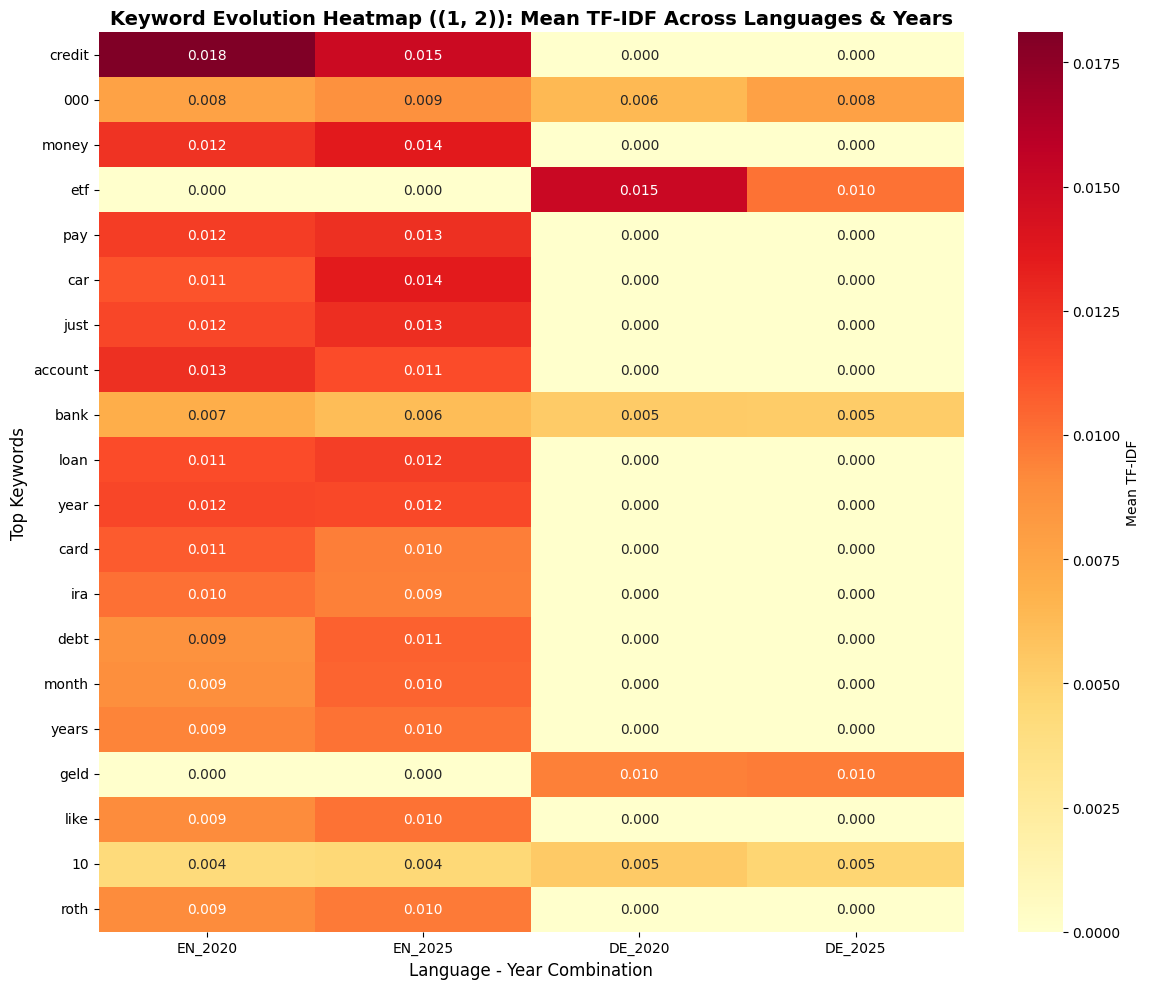

✓ Saved heatmap ((1, 2)): ./asset/tfidf_keyword_evolution_heatmap_(1, 2).png


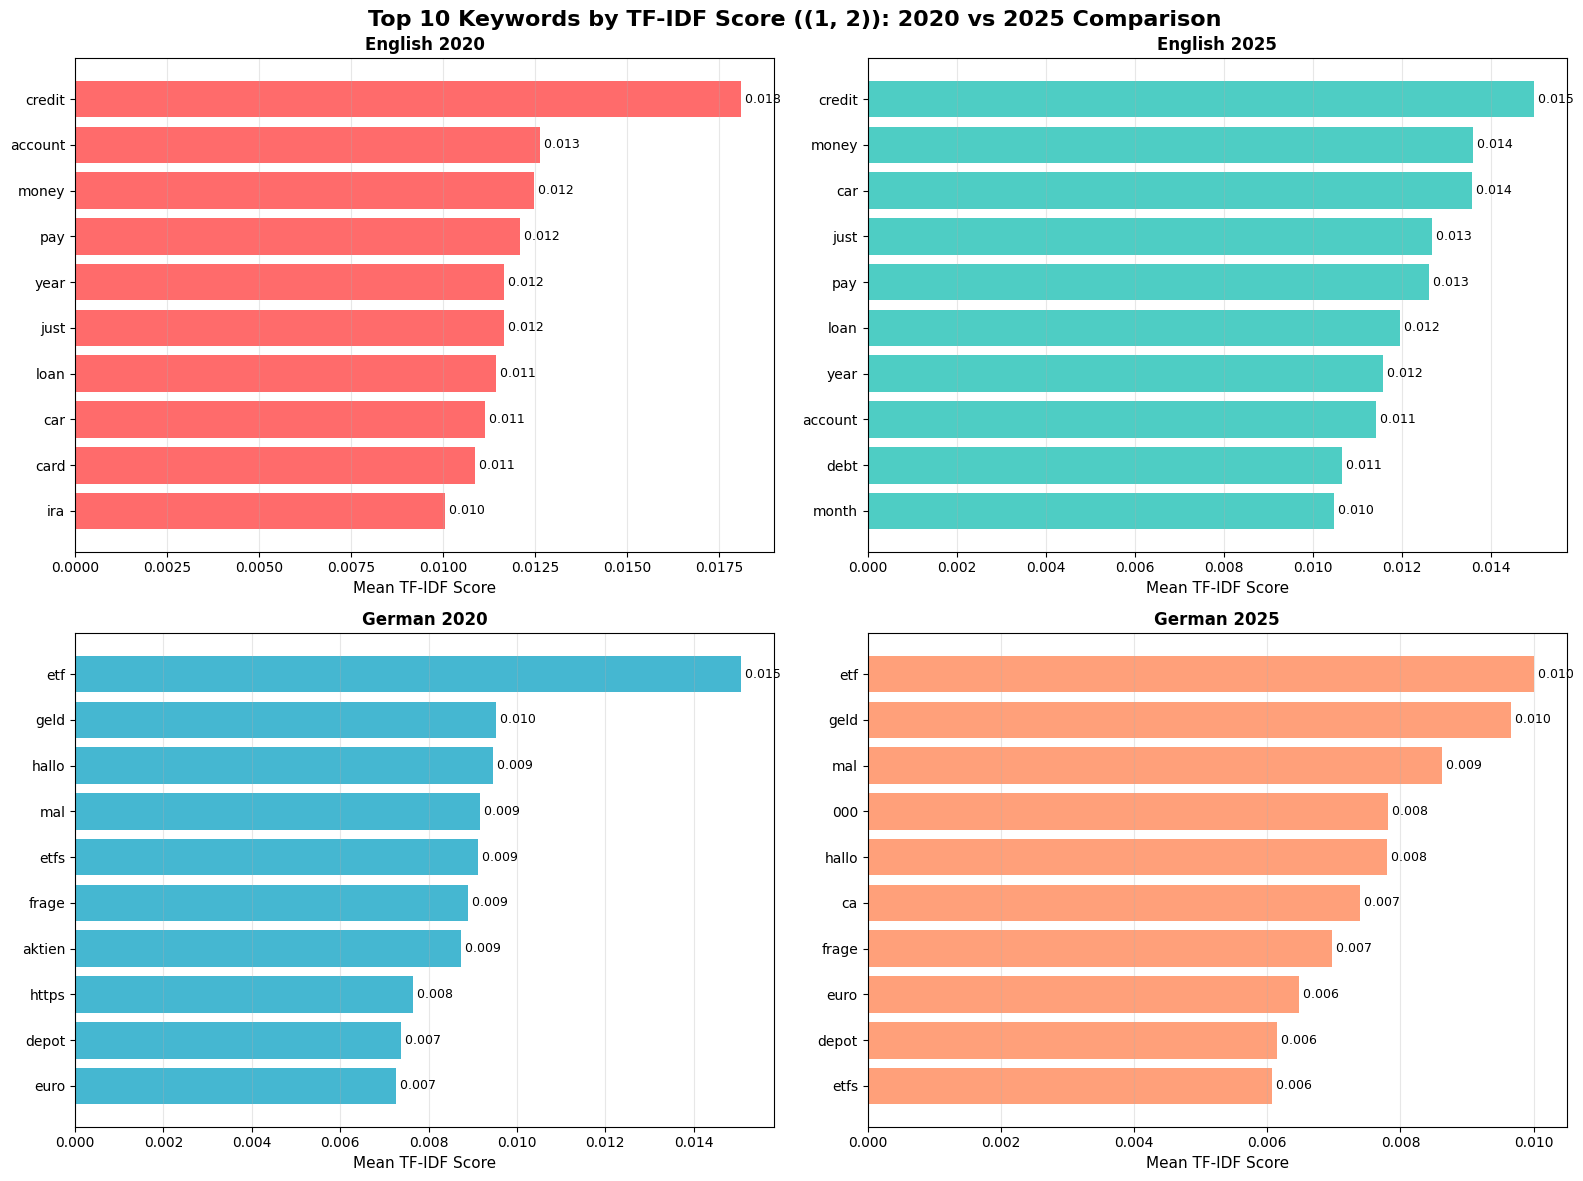

✓ Saved faceted bar chart ((1, 2)): ./asset/tfidf_faceted_bar_chart_(1, 2).png

Generating visualizations for (2, 3) n-grams (bigrams & trigrams)


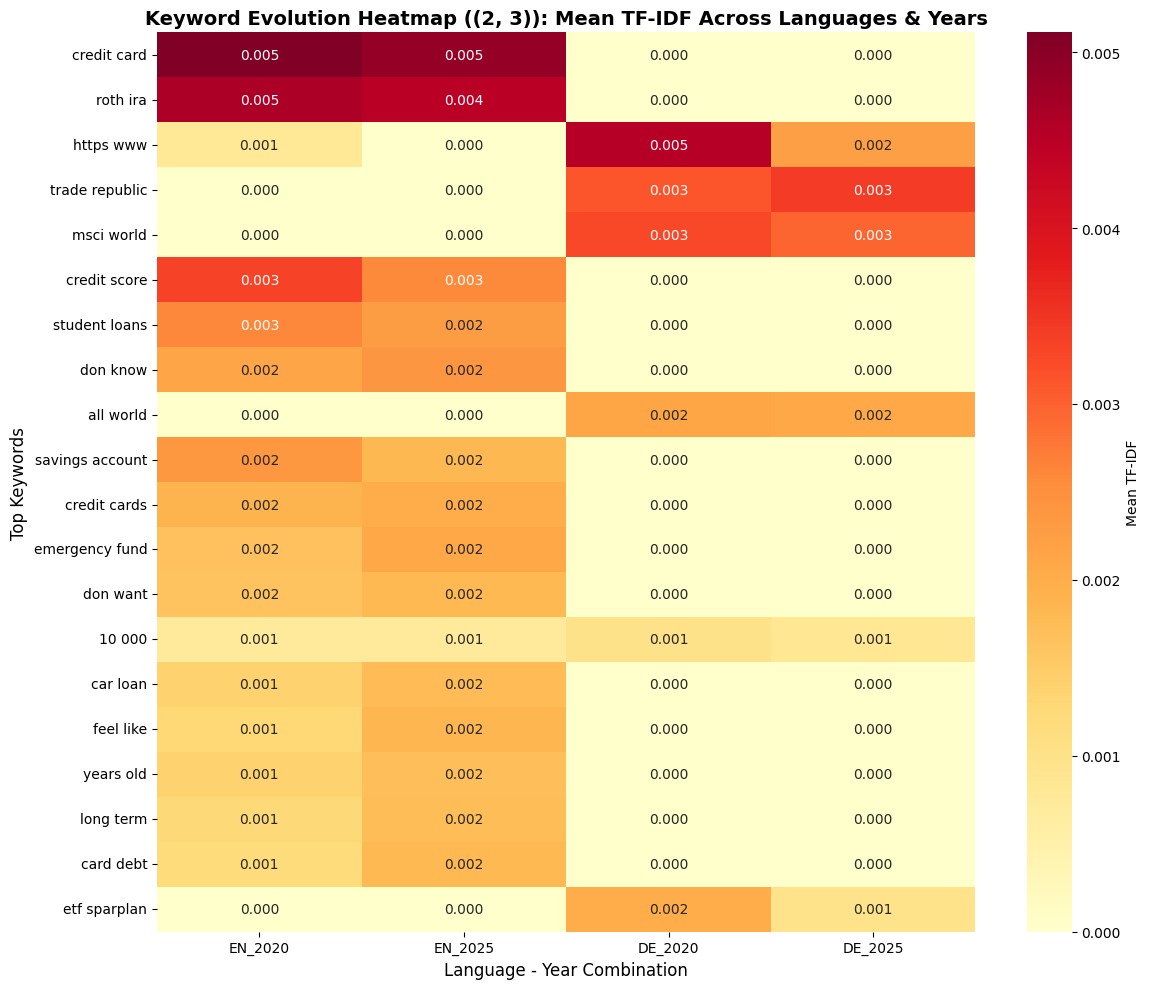

✓ Saved heatmap ((2, 3)): ./asset/tfidf_keyword_evolution_heatmap_(2, 3).png


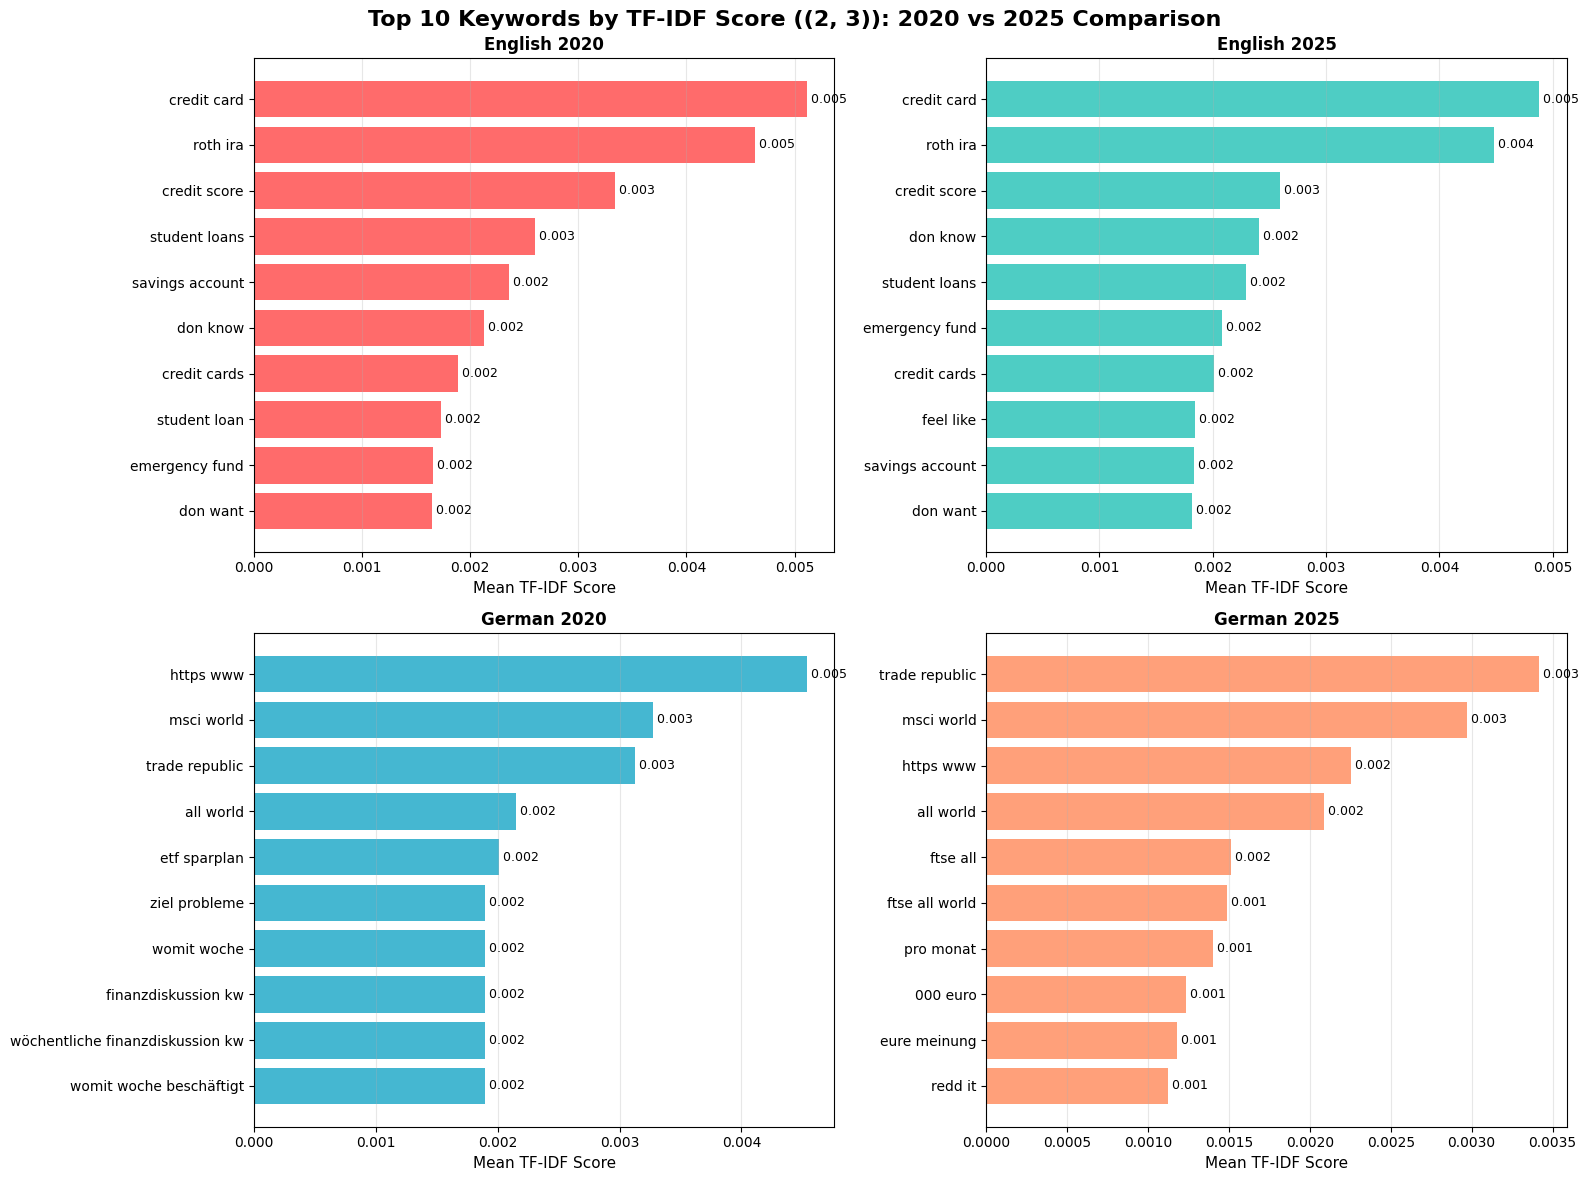

✓ Saved faceted bar chart ((2, 3)): ./asset/tfidf_faceted_bar_chart_(2, 3).png


In [21]:
# Visualization: Keyword Evolution Heatmap & Faceted Bar Chart (for both (1,2) and (2,3) n-grams)
import seaborn as sns
import matplotlib.patches as mpatches

# Extract (1,2) and (2,3) ngram results
tfidf_unigram_bigram = {k: v for k, v in tfidf_results.items() if '(1, 2)' in k}
tfidf_bigram_trigram = {k: v for k, v in tfidf_results.items() if '(2, 3)' in k}

def create_tfidf_visualizations(tfidf_dict, ngram_type):
    """Generate heatmap and faceted bar chart for given n-gram type"""
    if not tfidf_dict:
        print(f"No data found for {ngram_type}")
        return
    
    # ============================================
    # Heatmap: Keyword Evolution
    # ============================================
    all_terms_tfidf = {}
    for key, data in tfidf_dict.items():
        for idx, row in data['tfidf'].iterrows():
            term = row['term']
            score = row['mean_tfidf']
            if term not in all_terms_tfidf:
                all_terms_tfidf[term] = {}
            all_terms_tfidf[term][key] = score

    # Get top 20 terms by total TF-IDF score
    top_terms = sorted(all_terms_tfidf.items(), 
                       key=lambda x: sum(x[1].values()), 
                       reverse=True)[:20]

    # Build heatmap DataFrame
    heatmap_data_viz = {}
    for term, scores in top_terms:
        # Extract language_year from key format (e.g., "English_2020" from "English_2020_(1, 2)")
        heatmap_data_viz[term] = {
            'EN_2020': scores.get(f'English_2020_{ngram_type}', 0),
            'EN_2025': scores.get(f'English_2025_{ngram_type}', 0),
            'DE_2020': scores.get(f'German_2020_{ngram_type}', 0),
            'DE_2025': scores.get(f'German_2025_{ngram_type}', 0),
        }

    heatmap_df_viz = pd.DataFrame(heatmap_data_viz).T

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(heatmap_df_viz, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Mean TF-IDF'}, ax=ax)
    ax.set_title(f'Keyword Evolution Heatmap ({ngram_type}): Mean TF-IDF Across Languages & Years', fontsize=14, fontweight='bold')
    ax.set_xlabel('Language - Year Combination', fontsize=12)
    ax.set_ylabel('Top Keywords', fontsize=12)
    plt.tight_layout()
    heatmap_file = os.path.join(ASSET_DIR, f'tfidf_keyword_evolution_heatmap_{ngram_type}.png')
    plt.savefig(heatmap_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved heatmap ({ngram_type}): {heatmap_file}")

    # ============================================
    # Faceted Bar Chart: Top 10 per period
    # ============================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Top 10 Keywords by TF-IDF Score ({ngram_type}): 2020 vs 2025 Comparison', fontsize=16, fontweight='bold')

    periods = [
        (f'English_2020_{ngram_type}', axes[0, 0], 'English 2020'),
        (f'English_2025_{ngram_type}', axes[0, 1], 'English 2025'),
        (f'German_2020_{ngram_type}', axes[1, 0], 'German 2020'),
        (f'German_2025_{ngram_type}', axes[1, 1], 'German 2025'),
    ]

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

    for idx, (key, ax, title) in enumerate(periods):
        if key in tfidf_dict:
            df_top10 = tfidf_dict[key]['tfidf'].head(10)
            df_top10 = df_top10.iloc[::-1]
            
            bars = ax.barh(range(len(df_top10)), df_top10['mean_tfidf'], color=colors[idx])
            ax.set_yticks(range(len(df_top10)))
            ax.set_yticklabels(df_top10['term'], fontsize=10)
            ax.set_xlabel('Mean TF-IDF Score', fontsize=11)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            
            # Add value labels on bars
            for i, (idx_val, row) in enumerate(df_top10.iterrows()):
                ax.text(row['mean_tfidf'], i, f" {row['mean_tfidf']:.3f}", 
                       va='center', fontsize=9)

    plt.tight_layout()
    barchart_file = os.path.join(ASSET_DIR, f'tfidf_faceted_bar_chart_{ngram_type}.png')
    plt.savefig(barchart_file, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved faceted bar chart ({ngram_type}): {barchart_file}")

# Generate visualizations for both n-gram types
print("=" * 60)
print("Generating visualizations for (1, 2) n-grams (unigrams & bigrams)")
print("=" * 60)
create_tfidf_visualizations(tfidf_unigram_bigram, '(1, 2)')

print("\n" + "=" * 60)
print("Generating visualizations for (2, 3) n-grams (bigrams & trigrams)")
print("=" * 60)
create_tfidf_visualizations(tfidf_bigram_trigram, '(2, 3)')
